In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fastddm as ddm
import math
import warnings
from scipy.optimize import curve_fit

In [2]:
def gaussian_pdf(D, mu, sigma):
    D = np.asarray(D)
    pdf = np.exp(-0.5 * ((D - mu) / sigma) ** 2)
    pdf[D <= 0] = 0.0
    return pdf

def normalize_pdf(D, pdf):
    Z = np.trapezoid(pdf, D)
    return pdf / Z, Z

In [3]:
mu_D = 1.0 
sigma_D = 0.2

D_min = 0.0
D_max = mu_D + 6.0 * sigma_D
D_grid = np.linspace(D_min, D_max, 8000)

P_gaus = gaussian_pdf(D_grid, mu_D, sigma_D)
P_grid, Z = normalize_pdf(D_grid, P_gaus)

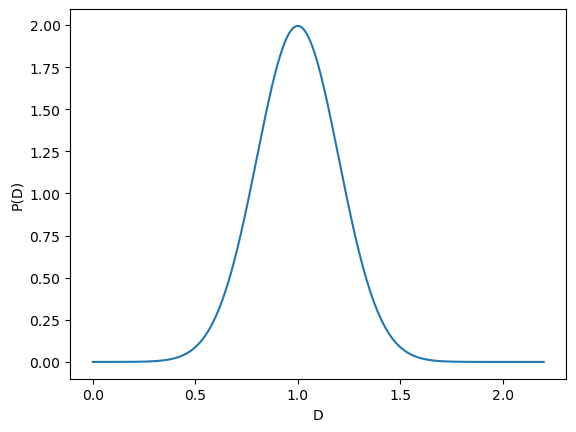

In [4]:
plt.figure()
plt.plot(D_grid, P_grid)
plt.xlabel("D")
plt.ylabel("P(D)")
plt.show()

In [42]:
def simulation(D_grid, P_grid, q_vals, t_vals):
    """
    Simulate f(q,t) via numerical integration on D_grid.
    Returns f with shape (N1, Nt).
    """
    Nq = len(q_vals)
    Nt = len(t_vals)
    f = np.empty((Nq, Nt), dtype=float)

    for i, q in enumerate(q_vals):
        qq = q * q
        for j, t in enumerate(t_vals):
            integrand = P_grid * np.exp(-D_grid * qq * t)
            f[i, j] = np.trapezoid(integrand, D_grid)
    return f

q_vals = np.linspace(0.5, 3.0, 25)     
t_vals = np.logspace(np.log(0.001)/np.log(10), np.log(200)/np.log(10))    
#t_vals = np.logspace(-3, np.log10(200))    

f_mat = simulation(D_grid, P_grid, q_vals, t_vals)  

np.random.seed(42)
noise_level = 0.01
noise = noise_level * np.random.normal(size=f_mat.shape) * np.sqrt(np.clip(1 - f_mat, 0, None))
f_noisy = f_mat + noise
f_noisy = np.clip(f_noisy, 1e-8, 1.0)

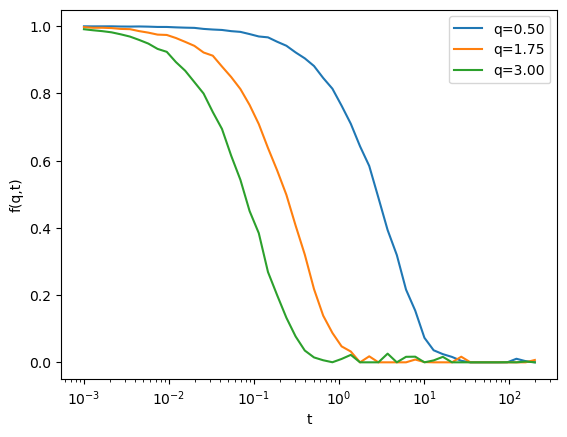

In [43]:
plt.figure()
for q in [q_vals[0], q_vals[len(q_vals)//2], q_vals[-1]]:
    i = np.argmin(np.abs(q_vals - q))
    plt.semilogx(t_vals, f_noisy[i], label=f"q={q_vals[i]:.2f}")
plt.xlabel("t")
plt.ylabel("f(q,t)")
plt.legend()
plt.show()

In [44]:
def make_cumulant_function(n_cumulants):
    """
    Generate a cumulants function.

    Parameters
    ----------
    n_cumulants : int
        Number of cumulants to include in the model. Each cumulant corresponds
        to a higher-order correction in the expansion.

    Returns
    -------
    cumulents_func : function
        Function of the form model(x, mu1, mu2, ..., mu{N})
        that returns ln f(x).
    """
    if n_cumulants > 4:
        warnings.warn(
            f"Using more than 4 cumulants (n={n_cumulants}) may lead to unstabilities",
            UserWarning
        )
    def cummulents_func(x, *params):
        x = np.asarray(x)
        ln_f = np.zeros_like(x, dtype=float)
        for n, mu_n in enumerate(params, start=1):
            ln_f += ((-1)**n) * mu_n * (x**n) / math.factorial(n)
        return ln_f
    return cummulents_func

In [45]:
def collapse_data(q_vals, t_vals, f_mat, f_min=0.05, f_max=1.0):
    x_data = []
    y_data = []

    for i, q in enumerate(q_vals):
        qq = q * q
        for j, t in enumerate(t_vals):
            f = f_mat[i, j]
            if f_min <= f <= f_max:
                x_data.append(qq * t)
                y_data.append(np.log(f))

    return np.asarray(x_data), np.asarray(y_data)

In [46]:
def fit_cumulants(q_vals, t_vals, f_mat, n_cumulants=3, f_min=0.05, f_max=1.0):
    
    x_data, y_data = collapse_data(q_vals, t_vals, f_mat, f_min=f_min, f_max=f_max)

    model = make_cumulant_function(n_cumulants)

    p0 = [1.0] + [0.0] * (n_cumulants - 1)

    params, cov = curve_fit(model, x_data, y_data, p0=p0, maxfev=20000)

    y_fit = model(x_data, *params)

    rmse = np.sqrt(np.mean((y_data - y_fit)**2))

    return params, cov, x_data, y_data, y_fit, rmse

In [52]:
params, cov, xa, ya, y_fit, rmse = fit_cumulants(
    q_vals, t_vals, f_noisy,
    n_cumulants=2,
    f_min=5e-2,
    f_max=1.0
)

#mu1, mu2, mu3, mu4, mu5, mu6 = params
#mu1, mu2, mu3, mu4 = params
#mu1, mu2, mu3 = params
mu1, mu2 = params
print("mu1 =", mu1)
print("mu2 =", mu2)
#print("mu3 =", mu3)
print("rmse =", rmse)

mu1 = 1.0130763863593137
mu2 = 0.05775991497398676
rmse = 0.03476237256873422


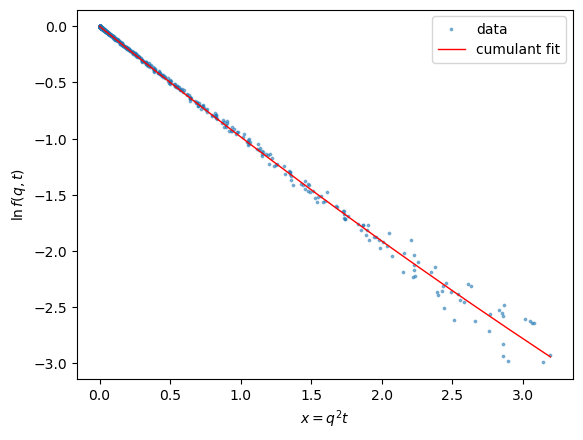

In [53]:
order = np.argsort(xa)

plt.figure()
plt.scatter(xa, ya, s=3, alpha=0.5, label="data")
plt.plot(xa[order], y_fit[order], color="red", linewidth=1, label="cumulant fit")
plt.xlabel(r"$x = q^2 t$")
plt.ylabel(r"$\ln f(q,t)$")
plt.legend()
plt.show()

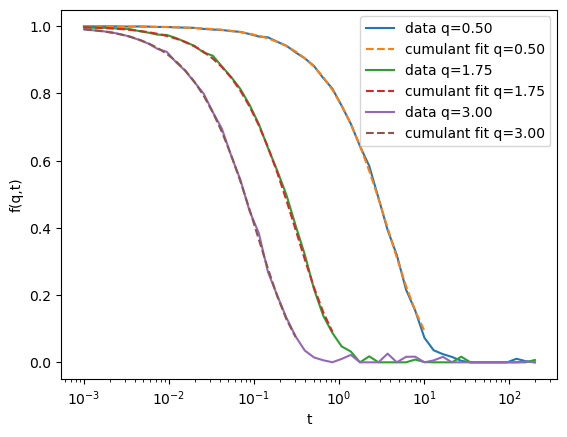

In [54]:
plt.figure()
q_list = [q_vals[0], q_vals[len(q_vals)//2], q_vals[-1]]
f_min = 5e-2
f_max = 1.0

for q in q_list:
    i = np.argmin(np.abs(q_vals - q))
    q_use = q_vals[i]

    plt.semilogx(t_vals, f_noisy[i], label=f"data q={q_use:.2f}")

    mask = (f_noisy[i] >= f_min) & (f_noisy[i] <= f_max)
    x_q = (q_use**2) * t_vals[mask]

    ln_f_fit_q = np.zeros_like(x_q)
    for n, mu_n in enumerate(params, start=1):
        ln_f_fit_q += ((-1)**n) * mu_n * (x_q**n) / math.factorial(n)

    f_fit_q = np.exp(ln_f_fit_q)

    plt.semilogx(t_vals[mask], f_fit_q, "--", label=f"cumulant fit q={q_use:.2f}")

plt.xlabel("t")
plt.ylabel("f(q,t)")
plt.legend()
plt.show()

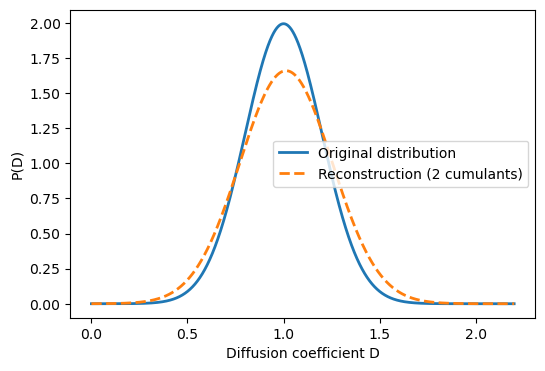

In [55]:
# reconstruct sigma
n_cumulants = len(params)
mu2_pos = max(mu2, 1e-12)
#m2_pos = np.abs(m2)
sigma_rec = np.sqrt(mu2_pos)

# reconstructed distribution
P_rec = (1/(np.sqrt(2*np.pi)*sigma_rec)) * np.exp(-(D_grid - mu1)**2/(2*mu2_pos))

# normalize
P_rec, Z = normalize_pdf(D_grid, P_rec)

plt.figure(figsize=(6,4))

plt.plot(D_grid, P_grid, label="Original distribution", linewidth=2)
plt.plot(D_grid, P_rec, "--", label=f"Reconstruction ({n_cumulants} cumulants)", linewidth=2)

plt.xlabel("Diffusion coefficient D")
plt.ylabel("P(D)")
plt.legend()

plt.show()